In [2]:
import pandas as pd    
import numpy as np    
import matplotlib.pyplot as plt    
import seaborn as sns    
import datetime    
import warnings    
warnings.filterwarnings('ignore')

#### 1.文件读取

In [3]:
data_train = pd.read_csv('train/train.csv')
data_test_a = pd.read_csv('testaa/testaa.csv')

#### 2.原始数据观察

##### 2.1训练集个数与维度

In [3]:
data_train.shape

(53480, 19)

##### 2.2测试集个数与维度

In [4]:
data_test_a.shape

(20054, 18)

##### 2.3数据类型

In [5]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53480 entries, 0 to 53479
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53480 non-null  int64  
 1   title             53480 non-null  int64  
 2   career            50872 non-null  float64
 3   zip_code          53480 non-null  int64  
 4   residence         53480 non-null  int64  
 5   loan              53480 non-null  int64  
 6   term              53480 non-null  int64  
 7   interest_rate     53480 non-null  float64
 8   issue_time        53480 non-null  int64  
 9   syndicated        53480 non-null  int64  
 10  installment       53480 non-null  int64  
 11  record_time       53480 non-null  int64  
 12  history_time      53480 non-null  int64  
 13  total_accounts    53480 non-null  float64
 14  balance_accounts  53480 non-null  float64
 15  balance_limit     53350 non-null  float64
 16  balance           53480 non-null  float6

### 3.数据缺失值与唯一值

There are 2 columns in train dataset with missing values.


<AxesSubplot:>

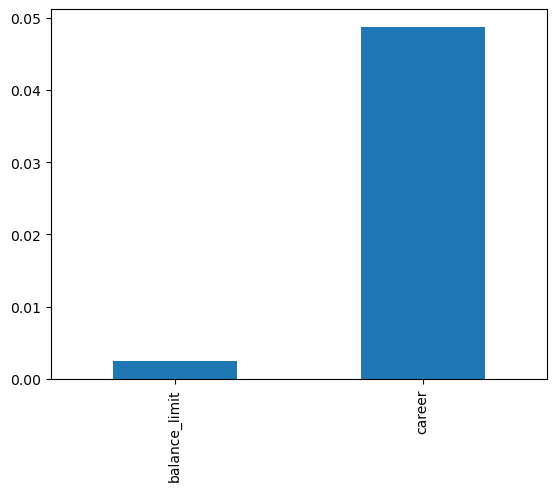

In [6]:
#总缺失值
print(f'There are {data_train.isnull().any().sum()} columns in train dataset with missing values.')
#确实率过50%的缺失值
have_null_fea_dict = (data_train.isnull().sum()/len(data_train)).to_dict()    
fea_null_moreThanHalf = {}    
for key,value in have_null_fea_dict.items():    
    if value > 0.5:    
        fea_null_moreThanHalf[key] = value
fea_null_moreThanHalf
#nan可视化    
missing = data_train.isnull().sum()/len(data_train)    
missing = missing[missing > 0]    
missing.sort_values(inplace=True)    
missing.plot.bar()

In [7]:
one_value_fea = [col for col in data_train.columns if data_train[col].nunique() <= 1]
one_value_fea_test = [col for col in data_test_a.columns if data_test_a[col].nunique() <= 1]
print(f'There are {len(one_value_fea)} columns in train dataset with one unique value.',one_value_fea)    
print(f'There are {len(one_value_fea_test)} columns in test dataset with one unique value.',one_value_fea_test)

There are 0 columns in train dataset with one unique value. []
There are 0 columns in test dataset with one unique value. []


In [57]:
#去掉唯一值与id
data_train.drop('id', axis=1, inplace = True)
data_train.drop('policyCode', axis=1, inplace = True)    

### 4.特征挑选

In [58]:
print(toad.__version__)

0.1.0


In [59]:
'''
pd.DataFrame.iteritems = pd.DataFrame.items  # 动态替换方法
import toad  # 必须在补丁后导入
toad.quality(data_train, target='isDefault', cpu_cores=0, iv_only=False)
# PS:若只想参考IV值，可以将iv_only=True，不然需要耗费很多时间
'''

"\npd.DataFrame.iteritems = pd.DataFrame.items  # 动态替换方法\nimport toad  # 必须在补丁后导入\ntoad.quality(data_train, target='isDefault', cpu_cores=0, iv_only=False)\n# PS:若只想参考IV值，可以将iv_only=True，不然需要耗费很多时间\n"

In [60]:
# 删除无预测能力的特征
for data in [data_train, data_test_a]:
    data.drop('n5', axis=1, inplace = True)            
    data.drop('n0', axis=1, inplace = True)
    data.drop('regionCode', axis=1, inplace = True)            
    data.drop('n4', axis=1, inplace = True)
    data.drop('n13', axis=1, inplace = True)            
    data.drop('n6', axis=1, inplace = True)
    data.drop('pubRec', axis=1, inplace = True)            
    data.drop('n8', axis=1, inplace = True)
    data.drop('revolBal', axis=1, inplace = True)            
    data.drop('openAcc', axis=1, inplace = True)
    data.drop('postCode', axis=1, inplace = True)            
    data.drop('pubRecBankruptcies', axis=1, inplace = True)
    data.drop('delinquency_2years', axis=1, inplace = True)            
    data.drop('totalAcc', axis=1, inplace = True)
    data.drop('applicationType', axis=1, inplace = True)            
    data.drop('n12', axis=1, inplace = True)
    data.drop('initialListStatus', axis=1, inplace = True)            
    data.drop('n11', axis=1, inplace = True)
    data.drop('purpose', axis=1, inplace = True)            
    data.drop('n1', axis=1, inplace = True)
    data.drop('employmentLength', axis=1, inplace = True)            
    data.drop('n7', axis=1, inplace = True)          
    data.drop('n10', axis=1, inplace = True)

### 5. 数值特征与类别特征

In [ ]:
# 两类特征进行分类
numerical_fea = list(data_train.select_dtypes(exclude=['object']).columns)                # 数值特征
category_fea = list(filter(lambda x: x not in numerical_fea, list(data_train.columns)))  # 类别特征 
 
# 将 label 去除
label = 'label'
numerical_fea.remove(label)
# 按照中位数，填充数值型特征
data_train[numerical_fea] = data_train[numerical_fea].fillna(data_train[numerical_fea].median())
data_test_a[numerical_fea] = data_test_a[numerical_fea].fillna(data_test_a[numerical_fea].median())
# 按照众数，填充类别型特征
for cate_fea in category_fea:
    data_train[cate_fea] = data_train[cate_fea].fillna(data_train[cate_fea].mode().values[0])
    data_test_a[cate_fea] = data_test_a[cate_fea].fillna(data_test_a[cate_fea].mode().values[0])
data_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   loanAmnt            800000 non-null  float64
 1   term                800000 non-null  int64  
 2   interestRate        800000 non-null  float64
 3   installment         800000 non-null  float64
 4   grade               800000 non-null  object 
 5   subGrade            800000 non-null  object 
 6   employmentTitle     800000 non-null  float64
 7   homeOwnership       800000 non-null  int64  
 8   annualIncome        800000 non-null  float64
 9   verificationStatus  800000 non-null  int64  
 10  issueDate           800000 non-null  object 
 11  isDefault           800000 non-null  int64  
 12  dti                 800000 non-null  float64
 13  ficoRangeLow        800000 non-null  float64
 14  ficoRangeHigh       800000 non-null  float64
 15  revolUtil           800000 non-nul

In [12]:
# 两类特征进行分类
numerical_fea = list(data_train.select_dtypes(exclude=['object']).columns)                # 数值特征
category_fea = list(filter(lambda x: x not in numerical_fea, list(data_train.columns)))  # 类别特征 
 
# 将 label 去除
label = 'label'
numerical_fea.remove(label)
numerical_fea.remove('id')
print('There are',len(numerical_fea),'numerical features : ',numerical_fea);
print('There are',len(category_fea), 'category features : ',category_fea);

There are 16 numerical features :  ['title', 'career', 'zip_code', 'residence', 'loan', 'term', 'interest_rate', 'issue_time', 'syndicated', 'installment', 'record_time', 'history_time', 'total_accounts', 'balance_accounts', 'balance_limit', 'balance']
There are 1 category features :  ['level']


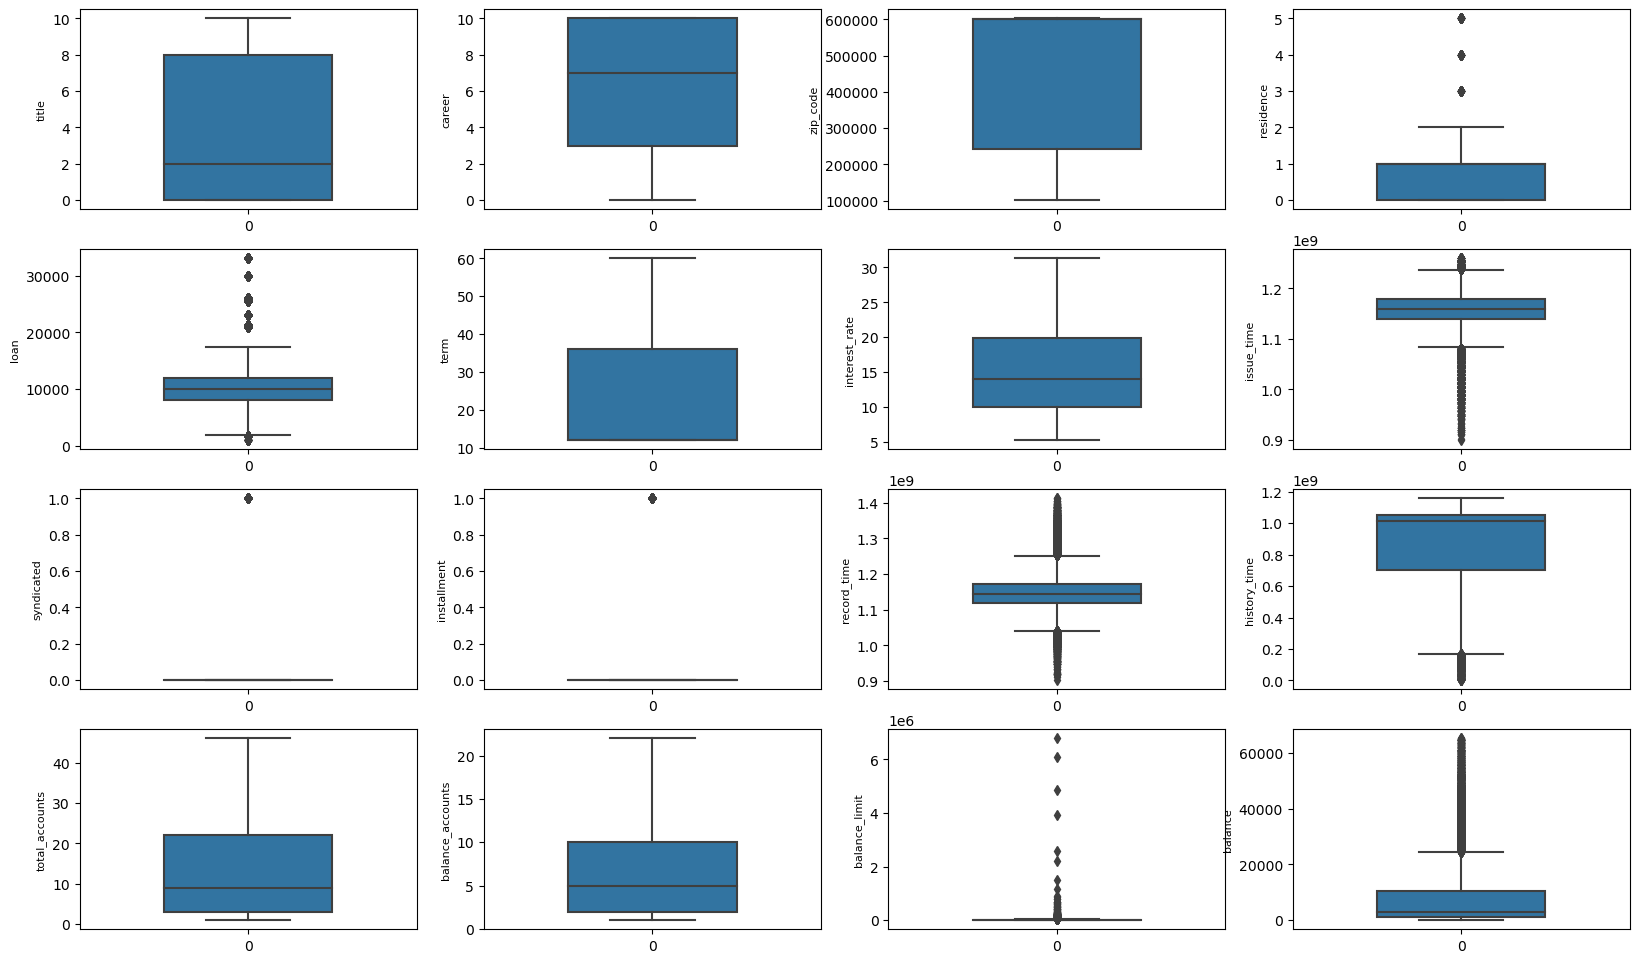

In [13]:
#对数值特征进行箱式图观察
# 画箱式图
column = numerical_fea # 列表头
fig = plt.figure(figsize=(20, 40))  # 指定绘图对象宽度和高度
for i in range(len(column)):
    plt.subplot(13, 4, i + 1)  # 13行3列子图
    sns.boxplot(data_train[column[i]], orient="v", width=0.5)  # 箱式图
    plt.ylabel(column[i], fontsize=8)
plt.show()


In [14]:
#根据算法区分
def get_numerical_serial_fea(data,feas):
    numerical_serial_fea = []                 # 连续变量
    numerical_noserial_fea = []               # 离散变量
    for fea in feas:
        temp = data[fea].nunique()
        if temp <= 10:
            numerical_noserial_fea.append(fea)
        else:
            numerical_serial_fea.append(fea)
    return numerical_serial_fea,numerical_noserial_fea
numerical_serial_fea,numerical_noserial_fea = get_numerical_serial_fea(data_train,numerical_fea)
print('算法区分连续型变量：',numerical_serial_fea)
print('算法区分离散型变量：',numerical_noserial_fea)

算法区分连续型变量： ['title', 'career', 'zip_code', 'loan', 'interest_rate', 'issue_time', 'record_time', 'history_time', 'total_accounts', 'balance_accounts', 'balance_limit', 'balance']
算法区分离散型变量： ['residence', 'term', 'syndicated', 'installment']


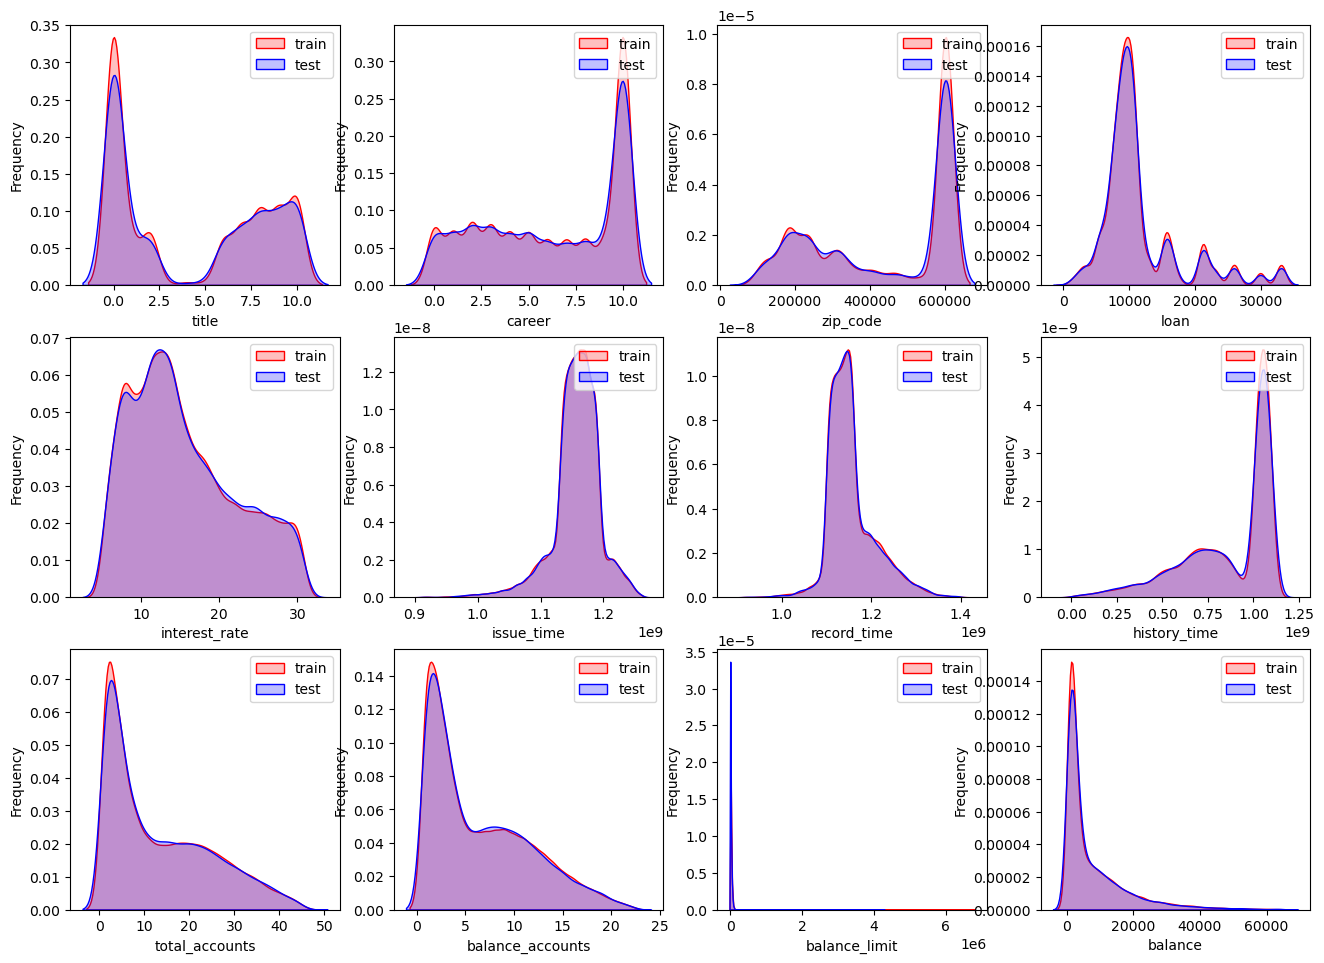

In [16]:
#对训练集与测试集数据进行可视化正态分布进行对比
#此处采用算法区分的连续型变量
dist_cols = 4
dist_rows = len(data_test_a[numerical_serial_fea].columns)
plt.figure(figsize=(4*dist_cols,4*dist_rows))

i=1
for col in data_test_a[numerical_serial_fea].columns:
    ax=plt.subplot(dist_rows,dist_cols,i)
    ax = sns.kdeplot(data_train[numerical_serial_fea][col], color="Red", shade=True)
    ax = sns.kdeplot(data_test_a[numerical_serial_fea][col], color="Blue", shade=True)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax = ax.legend(["train","test"])
    
    i+=1
plt.show()

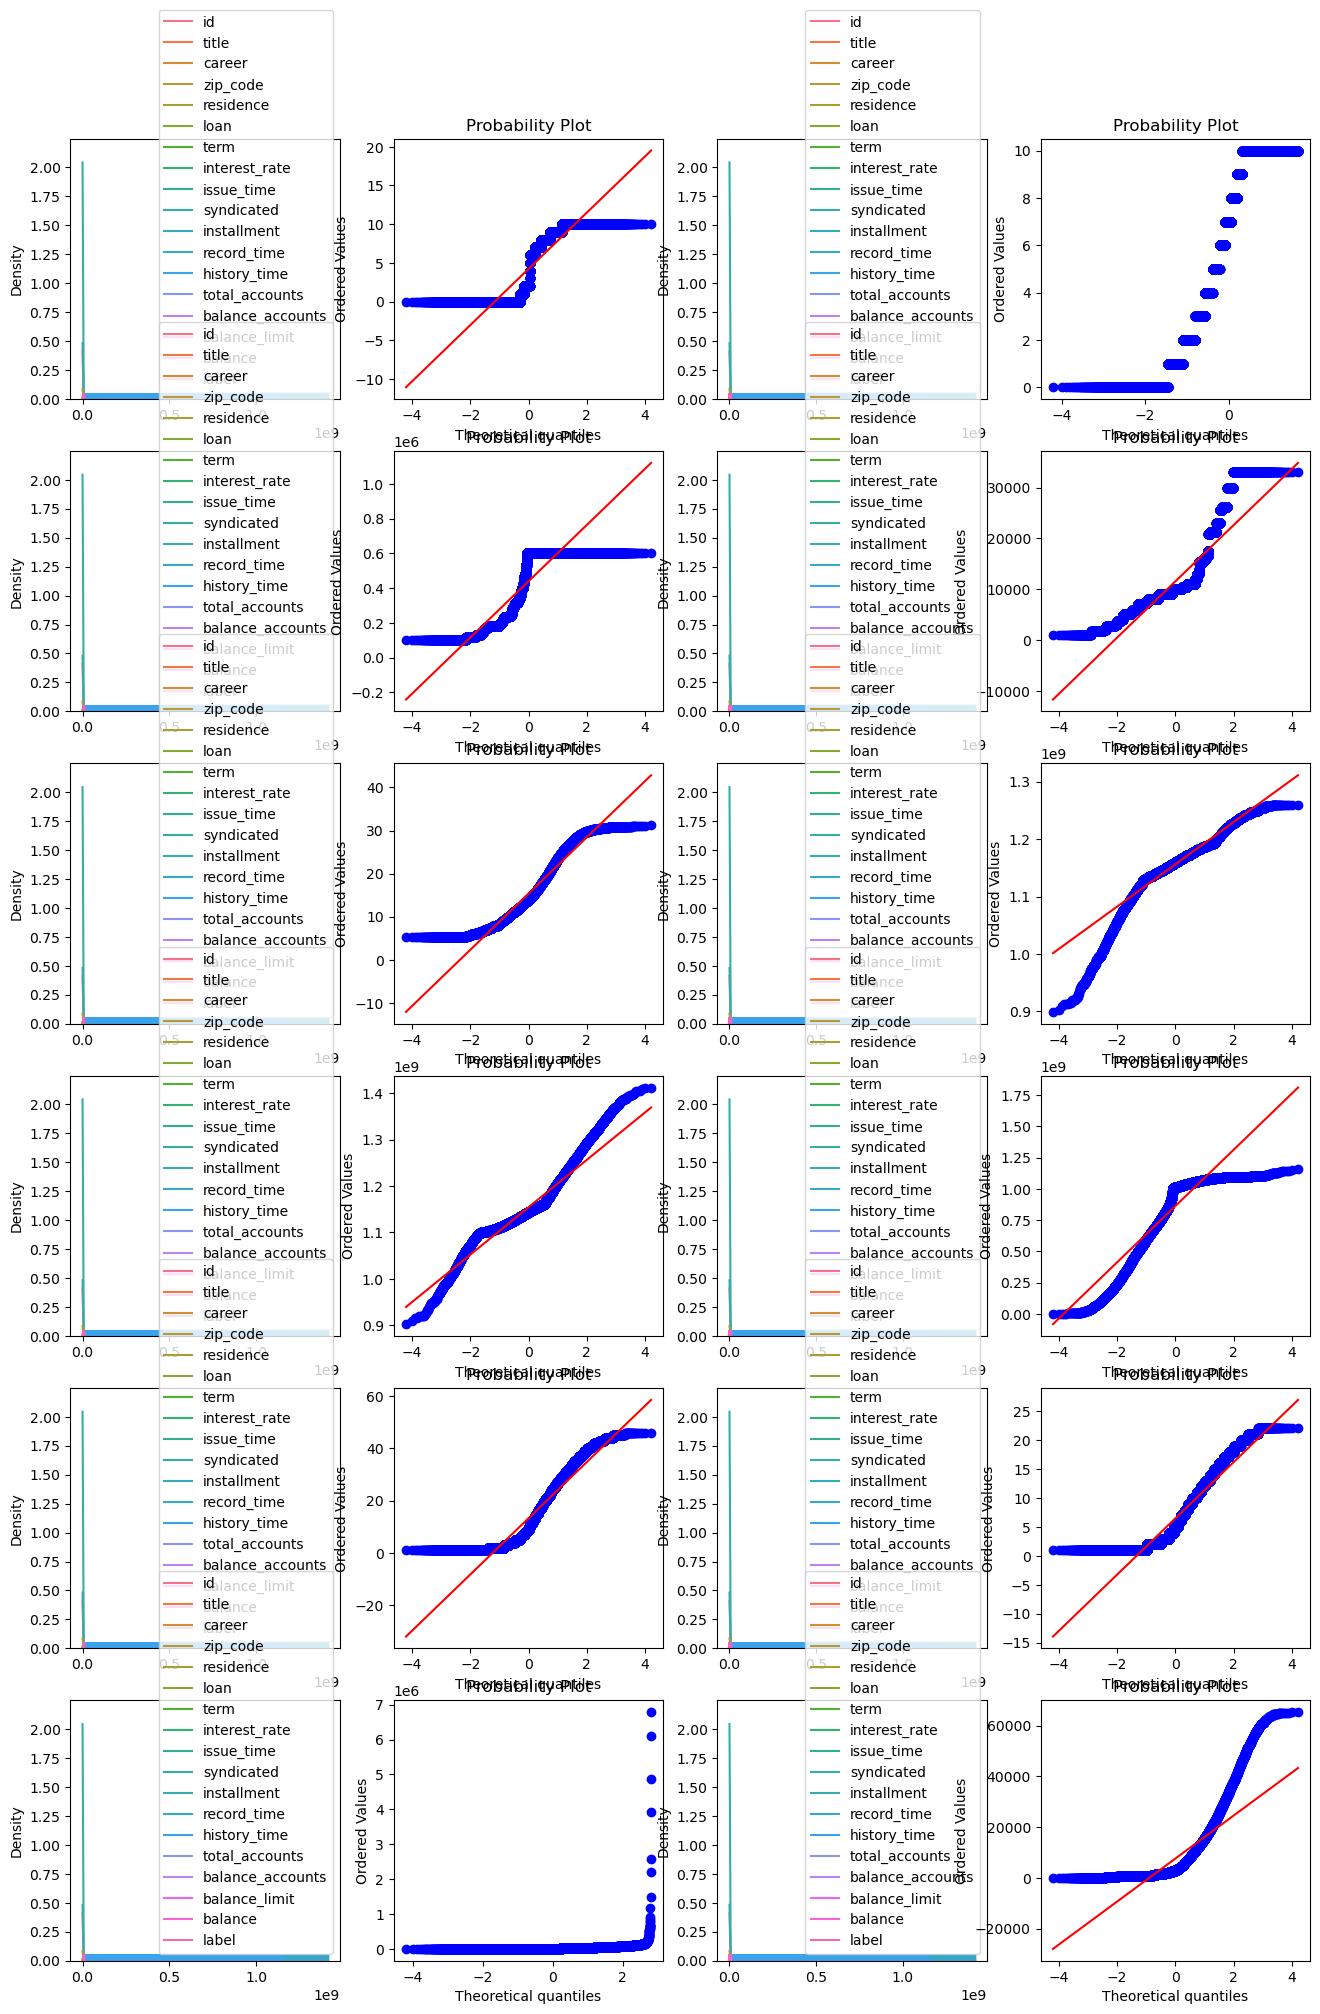

In [17]:
from scipy import stats
train_cols = 4
train_rows = len(data_train[numerical_serial_fea].columns)
plt.figure(figsize=(4*train_cols,4*train_rows))

i=0
for col in data_train[numerical_serial_fea].columns:
    i+=1
    ax=plt.subplot(train_rows,train_cols,i)
    # sns.distplot(data_train[numerical_serial_fea][col],fit=stats.norm)
    sns.histplot(data_train, kde=True, stat="density", bins=30, alpha=0.5)
    sns.rugplot(data_train, color="black") 
    i+=1
    ax=plt.subplot(train_rows,train_cols,i)
    res = stats.probplot(data_train[numerical_serial_fea][col], plot=plt)
plt.show()


In [6]:
# 通过观察数据类型共有5个object类型，因此进行特征转换
# 1. grade贷款等级共7个等级,观察分布
def level_to_num(level):
    grade_map = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4}
    grade = level[0]              # A/B/C/D/E
    sub = int(level[1])           # 0-5
    return grade_map[grade] * 6 + sub
data_train['level_num'] = data_train['level'].apply(level_to_num)
data_train.head()

,id,title,career,zip_code,residence,loan,term,interest_rate,issue_time,syndicated,installment,record_time,history_time,total_accounts,balance_accounts,balance_limit,balance,level,label,level_num
0,0,9,0.0,221373,1,7200,36,10.95,1238631967,0,1,1238630622,472006661,17.0,9.0,36200.0,13856.0,A4,0,4
1,1,8,10.0,311681,0,21300,36,12.95,1128212052,0,0,1161907665,763779041,17.0,9.0,20400.0,13773.0,B0,1,6
2,2,8,7.0,271562,1,10400,60,21.05,1249171509,0,0,1383958593,727143443,17.0,9.0,10800.0,2023.0,B4,0,10
3,3,7,2.0,522083,0,33050,36,16.40,1172882234,0,1,1214353935,687660346,17.0,9.0,24700.0,21992.0,B3,0,9
4,4,8,3.0,101026,1,5200,36,14.35,1172882384,0,0,1240274527,322012875,17.0,9.0,5100.0,1669.0,B2,1,8


In [15]:
data_train['syndicated'].value_counts()

0    52992
1      488
Name: syndicated, dtype: int64

In [63]:
#对于有优先级的数据，采用自映射编码（其他办法？）
# 1.grade
for data in [data_train, data_test_a]:
    data['grade'] = data['grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
# 2.subgrade
# 该函数用于将 subGrade 转换为数值等级
def get_sub_grade(grade, sub):
    # 处理缺失值（NaN）和浮点数
    if not isinstance(sub, str):
        return 0  # 或 grade * 10 + 0（按业务逻辑调整） 
    # 确保字符串长度足够
    if len(sub) < 2:
        return 0
    return grade*10+int(sub[1])
for data in [data_train, data_test_a]:
    data['subGrade'] = data.apply(lambda row: get_sub_grade(row['grade'],row['subGrade']), axis=1)
# 3.issueDate
import datetime
for data in [data_train, data_test_a]:
    data['issueDate'] = pd.to_datetime(data['issueDate'],format='%Y-%m-%d') # 将原始数据转换为 Pandas 的日期时间格式
    startdate = datetime.datetime.strptime('2007-06-01', '%Y-%m-%d') # '2007-06-01'设定为开始日期
    # 每个样本相对于 2007-06-01 的天数
    data['issueDateDT'] = data['issueDate'].apply(lambda x: x-startdate).dt.days # dt.days 将 Timedelta 对象转换为天数
# 4.earliesCreditLine
for data in [data_train, data_test_a]:
    data['earliesCreditLine'] = data['earliesCreditLine'].apply(lambda s: int(s[-4:])) # 只保留年份

In [65]:
# 划分数值特征中的离散型变量与连续型变量
# 划分数值型变量中的：连续变量和离散型变量
def get_numerical_serial_fea(data,feas):
    numerical_serial_fea = []                 # 连续变量
    numerical_noserial_fea = []               # 离散变量
    for fea in feas:
        temp = data[fea].nunique()
        if temp <= 10:
            numerical_noserial_fea.append(fea)
        else:
            numerical_serial_fea.append(fea)
    return numerical_serial_fea,numerical_noserial_fea
numerical_serial_fea,numerical_noserial_fea = get_numerical_serial_fea(data_train,numerical_fea)
print('连续型变量：',numerical_serial_fea)
print('离散型变量：',numerical_noserial_fea)

连续型变量： ['loanAmnt', 'interestRate', 'installment', 'employmentTitle', 'annualIncome', 'dti', 'ficoRangeLow', 'ficoRangeHigh', 'revolUtil', 'title', 'n2', 'n3', 'n9', 'n14']
离散型变量： ['term', 'homeOwnership', 'verificationStatus']


In [67]:
# 特征的分布情况： 对于近似正态分布或者接近线性关系的特征，不一定需要进行分箱操作。但对于偏态分布或者存在非线性关系的特征，分箱操作可能会有所帮助。
# 特征的重要性： 在特征选择过程中，通常会评估每个特征对目标变量的重要性。如果某个连续型数值特征对目标变量的影响较大，那么对其进行分箱操作可能会提高模型性能。
# 对部分连续性变量进行分箱操作
for data in [data_train, data_test_a]:
    data['loanAmnt'] = pd.qcut(data['loanAmnt'], 10, labels=False)
    data['interestRate'] = pd.qcut(data['interestRate'].rank(method='first'), 100, labels=False)
    data['installment'] = pd.qcut(data['installment'], 100, labels=False)
    data['annualIncome'] = pd.qcut(data['annualIncome'], 10, labels=False)
    data['dti'] = pd.qcut(data['dti'], 100, labels=False)
    data['revolUtil'] = pd.qcut(data['revolUtil'], 100, labels=False)

In [69]:
data_train.to_csv('data/processed_train.csv',index=False, encoding='utf-8-sig')
data_test_a.to_csv('data/processed_test.csv',index=False, encoding='utf-8-sig')